In [38]:
import os
from pathlib import Path
import pandas as pd

wd = Path(os.getcwd())
root = wd.parent 

if str(root).split('\\')[-1] == "TSDP":
    os.chdir(root)
    print(f"Working directory set to {root}")
else:
    print("Wrong root directory.")

df = pd.read_csv("datafiles/Big5_playerdata.csv")
df

Wrong root directory.


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,...,Pass Types_Sw,Pass Types_Crs,Pass Types_TI,Pass Types_CK,Corner Kicks_In,Corner Kicks_Out,Corner Kicks_Str,Outcomes_Cmp,Outcomes_Off,Outcomes_Blocks
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3.0,1.0,...,0.0,2.0,10.0,0.0,0.0,0.0,0.0,50.0,0.0,1.0
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4.0,1.0,...,0.0,5.0,11.0,0.0,0.0,0.0,0.0,47.0,0.0,1.0
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1.0,1.0,...,0.0,1.0,8.0,0.0,0.0,0.0,0.0,17.0,0.0,2.0
3,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36.0,0.0,0.0
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2849,2850,Edhy Zuliani,fr FRA,DF,Toulouse,fr Ligue 1,19.0,2004.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
2850,2851,Szymon Żurkowski,pl POL,MF,Empoli,it Serie A,26.0,1997.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0,0.0,2.0
2851,2852,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,25.0,1998.0,30.0,26.0,...,3.0,86.0,12.0,37.0,31.0,0.0,0.0,1237.0,12.0,27.0
2852,2853,Milan Đurić,ba BIH,FW,Monza,it Serie A,34.0,1990.0,18.0,13.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,131.0,0.0,1.0


In [39]:
df[['Playing Time_MP', '90s']].info()
df[['Playing Time_MP', '90s']].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2854 entries, 0 to 2853
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Playing Time_MP  2854 non-null   float64
 1   90s              2854 non-null   float64
dtypes: float64(2)
memory usage: 44.7 KB


,Playing Time_MP,90s
count,2854.000000,2854.000000
mean,19.012964,13.460792
std,11.502122,10.724564
min,1.000000,0.000000
25%,9.000000,3.500000
50%,20.000000,11.700000
75%,30.000000,22.200000
max,38.000000,38.000000


In [40]:
df = df[df['90s'] >= 5].reset_index(drop=True)
print(df.head())

   Rk               Player  Nation    Pos          Squad        Comp   Age  \
0   6     Yunis Abdelhamid  ma MAR     DF  Saint-Étienne  fr Ligue 1  36.0   
1   7        Himad Abdelli  dz ALG  MF,FW         Angers  fr Ligue 1  24.0   
2   8  Mohamed Abdelmoneim  eg EGY     DF           Nice  fr Ligue 1  25.0   
3   9             Ali Abdi  tn TUN  DF,MF           Nice  fr Ligue 1  30.0   
4  11                 Abel  es ESP     DF        Osasuna  es La Liga  23.0   

     Born  Playing Time_MP  Playing Time_Starts  ...  Pass Types_Sw  \
0  1987.0             16.0                 11.0  ...            0.0   
1  1999.0             32.0                 32.0  ...           13.0   
2  1999.0             12.0                 10.0  ...            7.0   
3  1993.0             25.0                 17.0  ...            2.0   
4  2000.0             35.0                 20.0  ...            2.0   

   Pass Types_Crs  Pass Types_TI  Pass Types_CK  Corner Kicks_In  \
0             0.0            3.0    

In [41]:
import pandas as pd

df90 = df.copy()

# --- 1) Kontextuális / nem normalizálandó változók ---
context_cols = [
    "Rk", "Player", "Nation", "Pos", "Squad", "Comp",
    "Age", "Born"
]

# Playing time / kontextuális idők
context_cols += [col for col in df.columns 
                 if col.startswith("Playing Time") or col == "90s"]

# --- 2) Százalékos változók ---
percent_cols = [col for col in df.columns 
                if "%" in col or col.endswith("Won%") or col.endswith("Cmp%")]

# --- 3) Per90 változók ---
per90_cols = [col for col in df.columns 
              if "/90" in col or "Per 90" in col]

# --- 4) Összes kizárt változó ---
exclude_cols = set(context_cols + percent_cols + per90_cols)

# --- 5) Normalizálandó változók ---
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
normalizable_cols = [col for col in numeric_cols if col not in exclude_cols]

# --- 6) Normalizálás: oszd el a 90s-szel ---
df90[normalizable_cols] = df[normalizable_cols].div(df["90s"], axis=0)

# Kapusok nélkül 
df90 = df90[df90['Pos'] != 'GK'].reset_index(drop=True)
df90


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,...,Pass Types_Sw,Pass Types_Crs,Pass Types_TI,Pass Types_CK,Corner Kicks_In,Corner Kicks_Out,Corner Kicks_Str,Outcomes_Cmp,Outcomes_Off,Outcomes_Blocks
0,6,Yunis Abdelhamid,ma MAR,DF,Saint-Étienne,fr Ligue 1,36.0,1987.0,16.0,11.0,...,0.000000,0.000000,0.260870,0.000000,0.000000,0.000000,0.0,38.086957,0.173913,0.086957
1,7,Himad Abdelli,dz ALG,"MF,FW",Angers,fr Ligue 1,24.0,1999.0,32.0,32.0,...,0.411392,1.392405,0.474684,0.316456,0.158228,0.063291,0.0,43.449367,0.316456,0.981013
2,8,Mohamed Abdelmoneim,eg EGY,DF,Nice,fr Ligue 1,25.0,1999.0,12.0,10.0,...,0.736842,0.210526,0.526316,0.000000,0.000000,0.000000,0.0,49.578947,0.000000,0.210526
3,9,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,30.0,1993.0,25.0,17.0,...,0.129032,3.290323,7.096774,0.000000,0.000000,0.000000,0.0,32.387097,0.322581,1.419355
4,11,Abel,es ESP,DF,Osasuna,es La Liga,23.0,2000.0,35.0,20.0,...,0.086957,3.695652,8.956522,0.000000,0.000000,0.000000,0.0,33.739130,0.173913,2.043478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827,2847,Yanis Zouaoui,dz ALG,"DF,FW",Le Havre,fr Ligue 1,30.0,1994.0,17.0,9.0,...,0.092593,10.185185,8.240741,4.537037,3.055556,1.388889,0.0,37.777778,0.185185,1.666667
1828,2848,Igor Zubeldia,es ESP,DF,Real Sociedad,es La Liga,27.0,1997.0,28.0,27.0,...,0.476190,0.039683,0.039683,0.000000,0.000000,0.000000,0.0,50.833333,0.317460,0.198413
1829,2849,Martín Zubimendi,es ESP,MF,Real Sociedad,es La Liga,25.0,1999.0,36.0,33.0,...,0.334347,0.364742,0.030395,0.030395,0.000000,0.000000,0.0,45.045593,0.212766,0.729483
1830,2852,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,25.0,1998.0,30.0,26.0,...,0.116279,3.333333,0.465116,1.434109,1.201550,0.000000,0.0,47.945736,0.465116,1.046512


In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =============== 1) Numerikus adatok kiválasztása ===============
numeric_cols = df90.select_dtypes(include=["float64", "int64"]).columns
# Kontextuális oszlopok kihagyása, ha tartalmazza az input
exclude_cols = ["Rk", "Player", "Nation", "Pos", "Squad", "Comp", "Age", "Born"]
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

X = df90[numeric_cols].fillna(0)

# =============== 2) Standardizálás ===============
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# =============== 3) PCA futtatása ===============
pca = PCA(n_components=10)   # változtatható
X_pca = pca.fit_transform(X_std)

# PCA eredmények dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)
pca_df["Player"] = df90["Player"].values
pca_df["Squad"] = df90["Squad"].values

# =============== 4) Magyarázott variancia ===============
explained = pca.explained_variance_ratio_
print("=== PCA Magyarázott variancia (%) ===")
for i, var in enumerate(explained, start=1):
    print(f"PC{i}: {var*100:.2f}%")

print("\nÖsszesen magyarázott variancia:", explained.sum()*100, "%")

# Magyarázóerők
import numpy as np
import pandas as pd

# === PCA LOADINGS / KOMPONENSEK ÉRTELMEZÉSE ===
# loading = a komponens és az eredeti standardizált változó közötti korreláció

# A scikit-learn PCA loadings számítása:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=numeric_cols
)

print("\n=== PCA LOADINGS (eredeti változók hatása a komponensekre) ===")
print(loadings)

# === LEGFONTOSABB változók komponensenként ===
def show_top_loadings(load_df, pc_number, top_n=10):
    pc = f"PC{pc_number}"
    print(f"\n=== {pc} – top {top_n} változó | abs érték szerint rendezve ===")
    print(
        load_df[pc]
        .abs()
        .sort_values(ascending=False)
        .head(top_n)
        .to_frame()
        .assign(sign=load_df[pc].loc[
            load_df[pc].abs().sort_values(ascending=False).head(top_n).index
        ])
    )

# Példa: első 3 komponens legfontosabb változói
show_top_loadings(loadings, 4, top_n=15)
show_top_loadings(loadings, 5, top_n=15)
show_top_loadings(loadings, 6, top_n=15)



# =============== 5) Játékos lekérdező függvény ===============

def query_player(identifier):
    """
    identifier lehet:
    - index (int)
    - játékos neve (string, case insensitive részleges keresés)
    """
    # ha számot kapunk → index
    if isinstance(identifier, int):
        row = pca_df.iloc[identifier]
        print(row)
        return row
    
    # ha string → névkeresés
    mask = pca_df["Player"].str.contains(identifier, case=False, na=False)
    results = pca_df[mask]
    
    if results.empty:
        print("Nincs találat ilyen névre!")
    else:
        print(results)
    return results

#query_player("Kerkez")

=== PCA Magyarázott variancia (%) ===
PC1: 29.67%
PC2: 14.03%
PC3: 7.12%
PC4: 4.38%
PC5: 3.68%
PC6: 3.55%
PC7: 2.61%
PC8: 2.35%
PC9: 1.99%
PC10: 1.86%

Összesen magyarázott variancia: 71.23412141521922 %

=== PCA LOADINGS (eredeti változók hatása a komponensekre) ===
                          PC1       PC2       PC3       PC4       PC5  \
Playing Time_MP      0.023103  0.022338 -0.039704  0.151618 -0.048955   
Playing Time_Starts -0.014042  0.015699 -0.071007  0.180852 -0.045378   
Playing Time_Min    -0.014516  0.016802 -0.074289  0.180345 -0.043965   
90s                 -0.014536  0.016790 -0.074319  0.180324 -0.043964   
Performance_Gls      0.115615 -0.014762 -0.136198 -0.050979 -0.124584   
...                       ...       ...       ...       ...       ...   
Corner Kicks_Out     0.027511  0.104303  0.021218  0.182921 -0.102088   
Corner Kicks_Str     0.005727  0.041541  0.014075  0.069682 -0.043092   
Outcomes_Cmp        -0.107693  0.120961 -0.106577 -0.056848  0.024058   
Ou

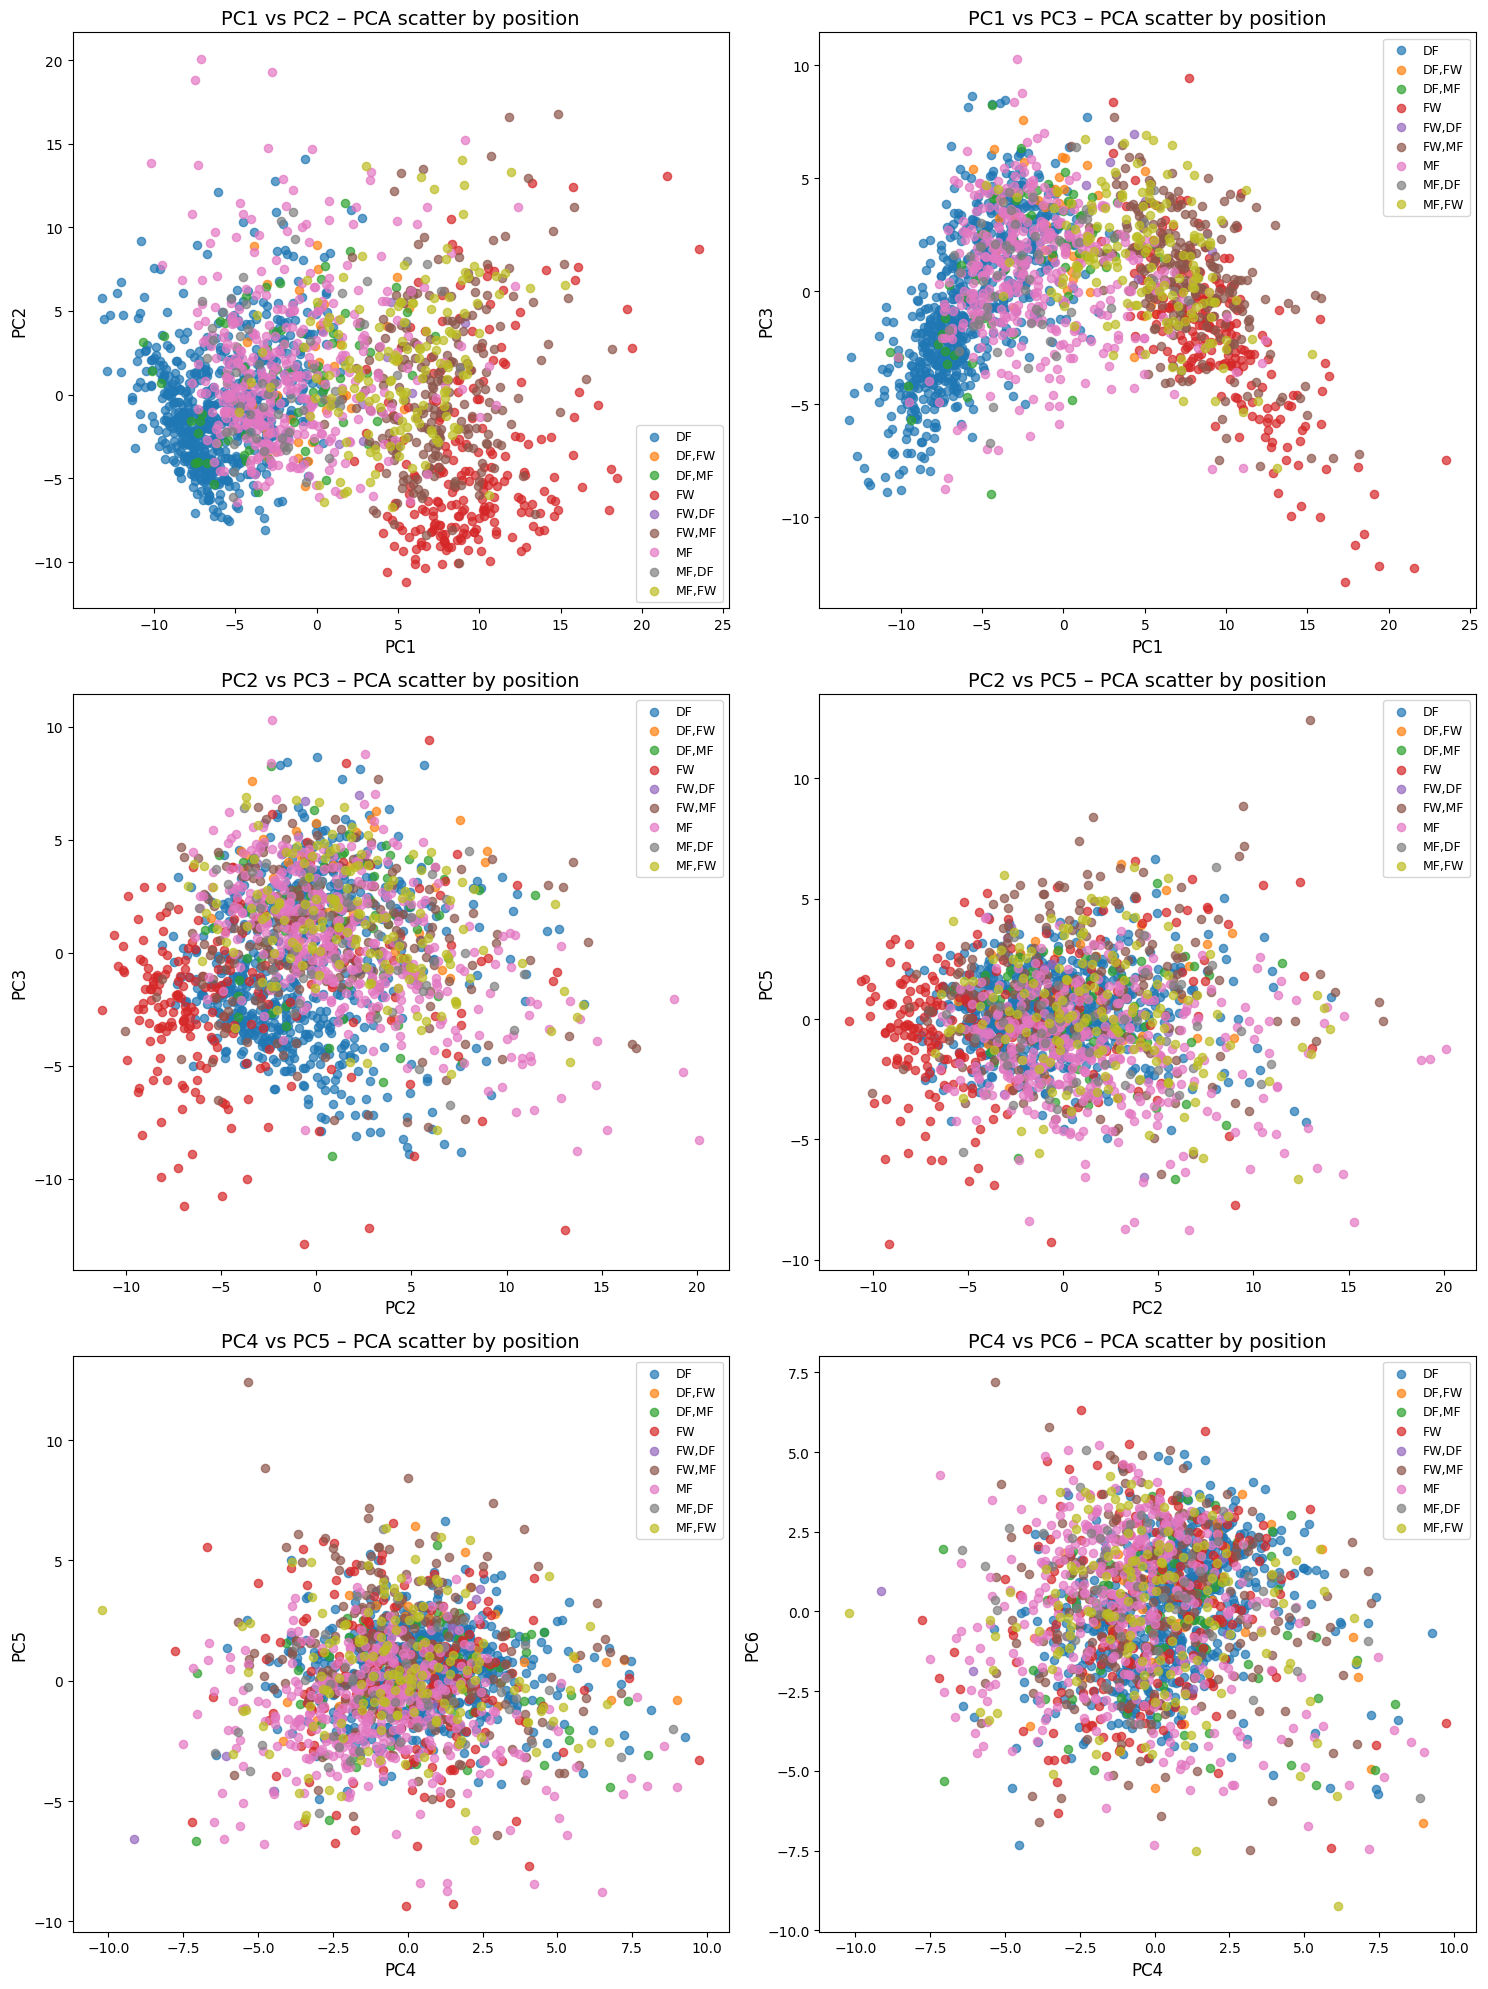

In [43]:
import matplotlib.pyplot as plt

df90['Pos_first'] = df90['Pos'].str.split(',').str[0]

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3"),
    ("PC2", "PC5"),
    ("PC4", "PC5"),
    ("PC4", "PC6"),
]
pca_df["Pos_first"] = df90["Pos_first"]
pca_df["Pos"] = df90["Pos"]

plt.figure(figsize=(15, 20))

for i, (pcx, pcy) in enumerate(pairs, 1):
    plt.subplot(3, 2, i)
    for pos in sorted(pca_df["Pos"].unique()):
        subset = pca_df[pca_df["Pos"] == pos]
        plt.scatter(
            subset[pcx], 
            subset[pcy], 
            label=pos,
            alpha=0.7,
            s=35
        )

    plt.xlabel(pcx, fontsize=12)
    plt.ylabel(pcy, fontsize=12)
    plt.title(f"{pcx} vs {pcy} – PCA scatter by position", fontsize=14)
    plt.legend(markerscale=1, fontsize=9)

plt.tight_layout()
plt.show()

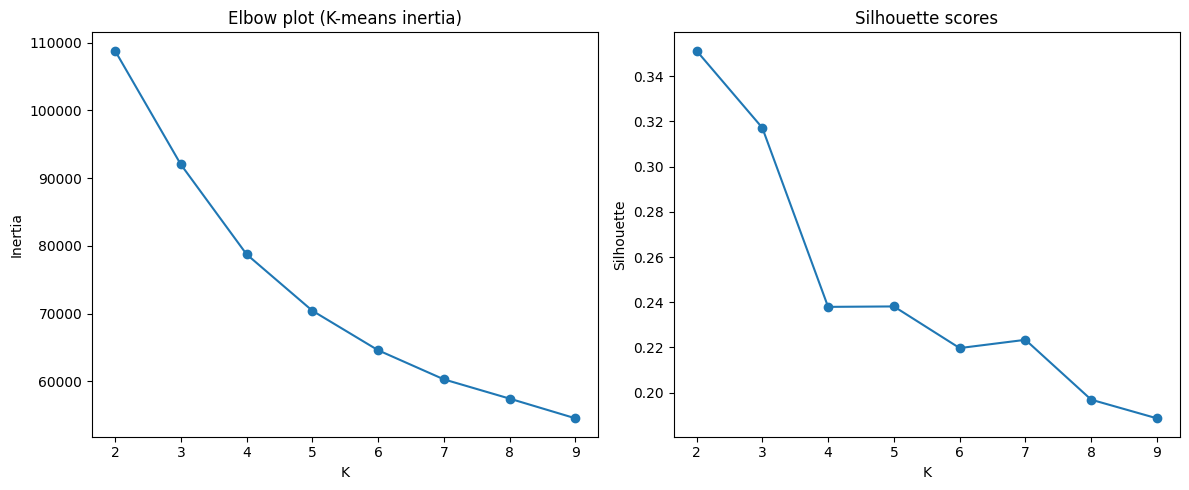

Optimal K = 2

=== Klaszter × Pozíció (Pos_first) kontingenciatábla ===
Pos_first   DF   FW   MF
Cluster                 
0           80  136  203
1          680    2  338
2            3  321   69

=== Arányosított (cluster row %) ===
Pos_first     DF     FW     MF
Cluster                       
0          0.191  0.325  0.484
1          0.667  0.002  0.331
2          0.008  0.817  0.176
              PC1       PC2       PC3       PC4       PC5       PC6
Cluster                                                            
0        4.487499  5.284031  0.568332  0.717699  0.248765 -0.316827
1       -4.993733 -0.610401  0.080987 -0.142668 -0.135199  0.198674
2        8.176453 -4.049365 -0.816127 -0.394896  0.085675 -0.177855


In [44]:
# Klaszterezés

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ------------------------------------
# 2) Optimális klaszterszám keresése
#    (elbow + silhouette)
# ------------------------------------
inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(pca_df[[f"PC{i+1}" for i in range(6)]])
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(pca_df[[f"PC{i+1}" for i in range(6)]], labels))

# Optional: grafikonok (ha szeretnéd)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow plot (K-means inertia)")
plt.xlabel("K")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(K_range, silhouettes, marker='o')
plt.title("Silhouette scores")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

# ------------------------------------
# 3) Válasszunk klaszterszámot
#    (általában a silhouette max. alapján)
# ------------------------------------
best_k = K_range[np.argmax(silhouettes)]
print("Optimal K =", best_k)
best_k = 3

kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=42)
pca_df["Cluster"] = kmeans.fit_predict(pca_df[[f"PC{i+1}" for i in range(6)]])

# ------------------------------------
# 4) Klaszter × Pozíció kontingenciatábla
# ------------------------------------
contingency = pd.crosstab(pca_df["Cluster"], pca_df["Pos_first"])
print("\n=== Klaszter × Pozíció (Pos_first) kontingenciatábla ===")
print(contingency)

# opcionális: arányok
print("\n=== Arányosított (cluster row %) ===")
print(contingency.div(contingency.sum(axis=1), axis=0).round(3))

print(pca_df.groupby("Cluster")[['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']].mean())


In [45]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------
# 1) POSZTOK SZÉTBONTÁSA
# --------------------------
DF_df = df90[df90["Pos_first"] == "DF"].copy()
MF_df = df90[df90["Pos_first"] == "MF"].copy()
FW_df = df90[df90["Pos_first"] == "FW"].copy()

# --------------------------
# 2) Alap feature set (numerikus)
# --------------------------
all_features = df90.select_dtypes(include=[np.number]).columns.tolist()

# ------------------------------------
# 3) Safe feature selector egy alhalmazra
# ------------------------------------
def get_valid_features(sub_df, feature_list):
    feats = []

    for col in feature_list:
        series = sub_df[col]

        # teljes NaN → töröljük
        if series.isna().all():
            continue

        # részleges NaN → nem jó PCA-nak
        if series.isna().sum() > 0:
            continue

        # nulla variancia → nem ad infót
        if series.std() == 0:
            continue

        feats.append(col)

    return feats


# ------------------------------------
# 4) PCA futtatása posztspecifikusan
# ------------------------------------
def run_safe_pca(sub_df, group_name, all_features, n_components=6):
    print(f"\n=== {group_name}: Feature cleaning ===")
    valid_feats = get_valid_features(sub_df, all_features)
    print(f"Valid features: {len(valid_feats)}")

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(sub_df[valid_feats])

    # PCA
    pca = PCA(n_components=min(n_components, X_scaled.shape[1]))
    pcs = pca.fit_transform(X_scaled)

    # PCA dataframe
    pcs_df = pd.DataFrame(
        pcs,
        index=sub_df.index,
        columns=[f"{group_name}_PC{i+1}" for i in range(pca.n_components_)]
    )

    # Loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        index=valid_feats,
        columns=pcs_df.columns
    )

    # Variance explained
    ev = np.round(pca.explained_variance_ratio_ * 100, 2)
    print(f"{group_name} explained variance (%):", ev, "Sum:", ev.sum())

    return pcs_df, pca, scaler, loadings, valid_feats


# ------------------------------------
# 5) PCA mindhárom posztra
# ------------------------------------
DF_pcs, DF_pca, DF_scaler, DF_loadings, DF_feats = run_safe_pca(DF_df, "DF", all_features)
MF_pcs, MF_pca, MF_scaler, MF_loadings, MF_feats = run_safe_pca(MF_df, "MF", all_features)
FW_pcs, FW_pca, FW_scaler, FW_loadings, FW_feats = run_safe_pca(FW_df, "FW", all_features)

# ------------------------------------
# 6) Visszacsatolás df90-be
# ------------------------------------
df90 = pd.concat([df90, DF_pcs, MF_pcs, FW_pcs], axis=1)

print("\nDone — PCA columns added.")

def print_top_loadings(loadings, group_name, top_n=15):
    """
    Egy PCA loadings DataFrame-ből kiírja minden komponens top változóit.
    """
    print(f"\n\n==================== {group_name} PCA – Top loadings ====================\n")

    for pc in loadings.columns:
        print(f"\n=== {group_name} | {pc} – top {top_n} abs(loadings) ===")
        df = (
            loadings[pc]
            .to_frame(name="loading")
            .assign(abs_loading=lambda x: x["loading"].abs())
            .sort_values("abs_loading", ascending=False)
            .head(top_n)
        )
        print(df)


# --- Kiírás mindhárom posztra ---
print_top_loadings(DF_loadings, "DF")
print_top_loadings(MF_loadings, "MF")
print_top_loadings(FW_loadings, "FW")




=== DF: Feature cleaning ===
Valid features: 146
DF explained variance (%): [24.77 13.24  8.17  5.15  4.05  3.04] Sum: 58.419999999999995

=== MF: Feature cleaning ===
Valid features: 148
MF explained variance (%): [24.48 16.95  5.55  4.83  4.47  3.05] Sum: 59.32999999999999

=== FW: Feature cleaning ===
Valid features: 147
FW explained variance (%): [27.81 13.85  5.76  4.73  4.25  3.29] Sum: 59.68999999999999

Done — PCA columns added.


==================== DF PCA – Top loadings ====================


=== DF | DF_PC1 – top 15 abs(loadings) ===
                          loading  abs_loading
Touches_Att 3rd          0.150917     0.150917
Progression_PrgR         0.148537     0.148537
Receiving_PrgR           0.148537     0.148537
SCA_SCA                  0.143880     0.143880
KP                       0.141435     0.141435
xAG                      0.139586     0.139586
Expected_xAG             0.139586     0.139586
PPA                      0.139184     0.139184
Per 90 Minutes_xAG      

In [46]:
df90

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,...,MF_PC3,MF_PC4,MF_PC5,MF_PC6,FW_PC1,FW_PC2,FW_PC3,FW_PC4,FW_PC5,FW_PC6
0,6,Yunis Abdelhamid,ma MAR,DF,Saint-Étienne,fr Ligue 1,36.0,1987.0,16.0,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7,Himad Abdelli,dz ALG,"MF,FW",Angers,fr Ligue 1,24.0,1999.0,32.0,32.0,...,-1.666449,-1.700561,-1.244813,0.307709,NaN,NaN,NaN,NaN,NaN,NaN
2,8,Mohamed Abdelmoneim,eg EGY,DF,Nice,fr Ligue 1,25.0,1999.0,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,30.0,1993.0,25.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11,Abel,es ESP,DF,Osasuna,es La Liga,23.0,2000.0,35.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827,2847,Yanis Zouaoui,dz ALG,"DF,FW",Le Havre,fr Ligue 1,30.0,1994.0,17.0,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1828,2848,Igor Zubeldia,es ESP,DF,Real Sociedad,es La Liga,27.0,1997.0,28.0,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1829,2849,Martín Zubimendi,es ESP,MF,Real Sociedad,es La Liga,25.0,1999.0,36.0,33.0,...,-1.488316,-2.456519,1.035254,2.058298,NaN,NaN,NaN,NaN,NaN,NaN
1830,2852,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,25.0,1998.0,30.0,26.0,...,0.504237,-2.912417,-3.541744,2.611514,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
# Néhány példa

players = {"DF": ["Stones", "Dijk", "Clauss"],
           "MF": ["De Bruyne", "Musiala"],
           "FW": ["Haaland", "Harry Kane", "Kvaratskhelia"]}

for pos, player_names in players.items():
    for player in player_names:
        print(df90[df90['Player'].str.contains(player)][["Player", "Squad"]+[col for col in df90.columns if f"{pos}_PC" in col]])
        print()

           Player            Squad    DF_PC1    DF_PC2    DF_PC3    DF_PC4  \
1592  John Stones  Manchester City -1.616616  7.145543  9.122529  2.606658   

        DF_PC5    DF_PC6  
1592 -3.206088 -1.013956  

               Player      Squad    DF_PC1    DF_PC2    DF_PC3    DF_PC4  \
1710  Virgil van Dijk  Liverpool -6.305977  8.986254  2.510139 -1.454582   

        DF_PC5    DF_PC6  
1710  0.568373  2.377217  

              Player Squad     DF_PC1    DF_PC2    DF_PC3    DF_PC4    DF_PC5  \
350  Jonathan Clauss  Nice  16.456692  3.481723  2.082806 -7.599067  8.410099   

       DF_PC6  
350 -2.504404  

              Player            Squad     MF_PC1    MF_PC2    MF_PC3  \
422  Kevin De Bruyne  Manchester City  15.607786  8.935744  5.605211   

       MF_PC4    MF_PC5    MF_PC6  
422  0.309282 -0.681404  1.357445  

             Player          Squad     MF_PC1    MF_PC2     MF_PC3    MF_PC4  \
1191  Jamal Musiala  Bayern Munich  16.751826  0.213808 -10.854021  1.300022   

     

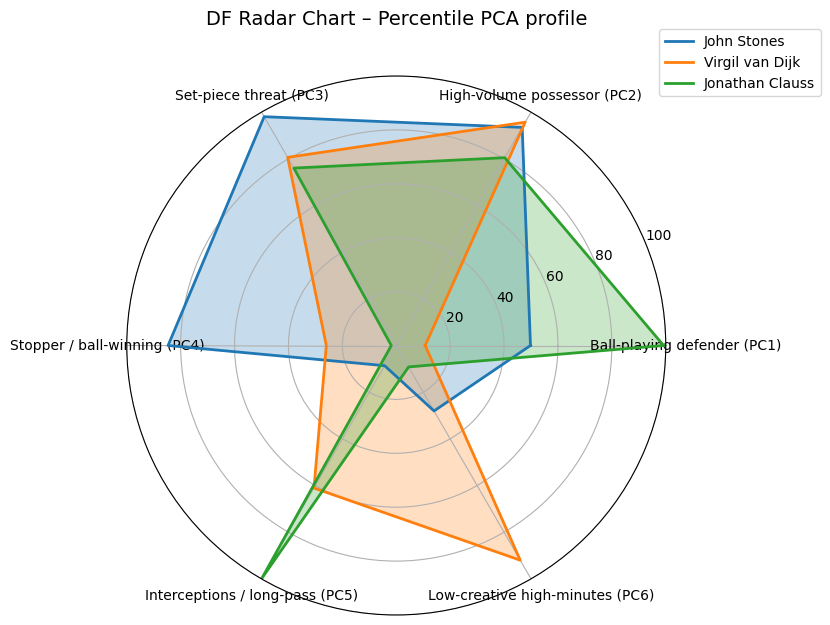

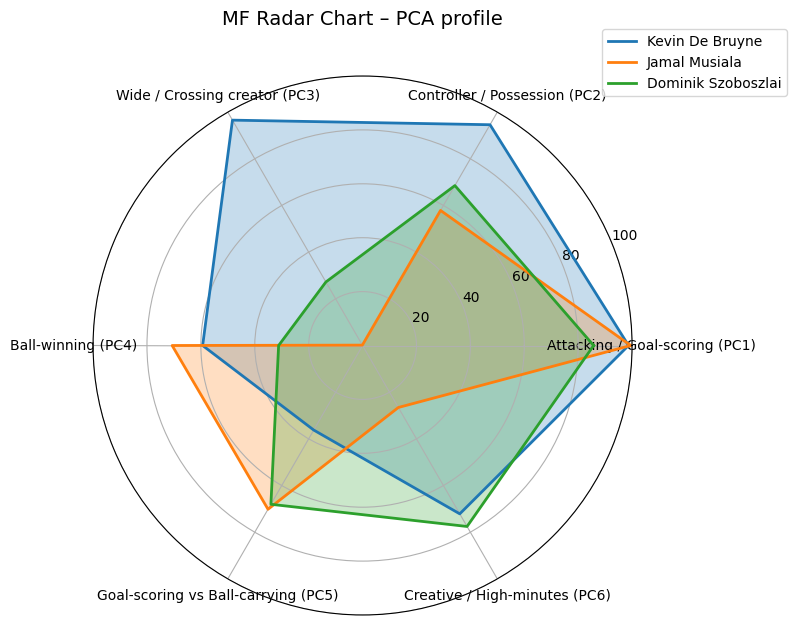

ValueError: x and y must have same first dimension, but have shapes (7,) and (13,)

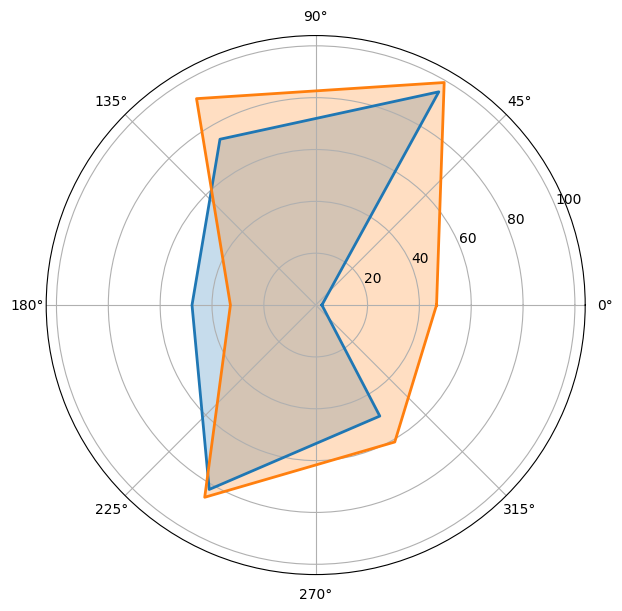

In [68]:
import matplotlib.pyplot as plt
import numpy as np

DF_players_list = ["John Stones", "Virgil van Dijk", "Jonathan Clauss"]
MF_players_list = ["Kevin De Bruyne", "Jamal Musiala", "Dominik Szoboszlai"]
FW_players_list = ["Erling Haaland", "Harry Kane", "Khvicha Kvaratskhelia"]

# ----------------------------------
# Percentilisek számítása
# ----------------------------------
def percentile_normalize(df, pc_columns):
    return df[pc_columns].rank(pct=True) * 100  # 0-100 percentilis

# ----------------------------------
# Radar plot függvény percentilisekkel
# ----------------------------------
def plot_radar_percentiles(pca_df, player_list, pc_columns, labels, title):
    # Percentilis normalizálás
    df_pct = percentile_normalize(pca_df, pc_columns)
    
    num_vars = len(pc_columns)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
    
    for player in player_list:
        row = df_pct.loc[pca_df["Player"] == player, pc_columns]
        if row.empty:
            print(f"Player {player} not found in dataframe.")
            continue
        values = row.values.flatten().tolist()
        values += values[:1]  # zárjuk a kört
        angles_full = angles + angles[:1]
        
        ax.plot(angles_full, values, label=player, linewidth=2)
        ax.fill(angles_full, values, alpha=0.25)
    
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylim(0, 100)
    ax.yaxis.grid(True)
    ax.xaxis.grid(True)
    ax.set_title(title, size=14, y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# ----------------------------------
# Példa DF radar chart percentilisekkel
# ----------------------------------
DF_labels = [
    "Ball-playing defender (PC1)",
    "High-volume possessor (PC2)",
    "Set-piece threat (PC3)",
    "Stopper / ball-winning (PC4)",
    "Interceptions / long-pass (PC5)",
    "Low-creative high-minutes (PC6)"
]
plot_radar_percentiles(df90, DF_players_list,
                       ["DF_PC1","DF_PC2","DF_PC3","DF_PC4","DF_PC5","DF_PC6"],
                       DF_labels,
                       "DF Radar Chart – Percentile PCA profile")

# ----------------------------------
# MF radar chart
# ----------------------------------
MF_labels = [
    "Attacking / Goal-scoring (PC1)",
    "Controller / Possession (PC2)",
    "Wide / Crossing creator (PC3)",
    "Ball-winning (PC4)",
    "Goal-scoring vs Ball-carrying (PC5)",
    "Creative / High-minutes (PC6)"
]
plot_radar_percentiles(df90, MF_players_list,
                   ["MF_PC1","MF_PC2","MF_PC3","MF_PC4","MF_PC5","MF_PC6"],
                   MF_labels,
                   "MF Radar Chart – PCA profile")

# ----------------------------------
# FW radar chart
# ----------------------------------
FW_labels = [
    "Link-up / False 9 (PC1)",
    "Poacher / Finisher (PC2)",
    "Creative winger / set-piece (PC3)",
    "Ball-carrying winger (PC4)",
    "Defensive forward / presser (PC5)",
    "Creative risk-taker (PC6)"
]
plot_radar_percentiles(df90, FW_players_list,
                   ["FW_PC1","FW_PC2","FW_PC3","FW_PC4","FW_PC5","FW_PC6"],
                   FW_labels,
                   "FW Radar Chart – PCA profile")
